# Influencer Marketing ROI & Performance Analysis

This notebook analyzes **150,000 influencer marketing campaigns** across Instagram, YouTube, TikTok, and Twitter to answer four business questions:

1. **ROI Analysis** — which platforms/categories return the most for the money spent
2. **Campaign Benchmarking** — how campaign types, influencer niches, and platforms compare
3. **Trend Analysis** — how engagement, reach, and sales move over time
4. **Influencer Selection** — which categories & campaign types to prioritize going forward

> ⚠️ **Important note on ROI**: the raw dataset has no `cost`/`spend` or `revenue` column — only `engagements`, `estimated_reach`, and `product_sales`. To make ROI calculable, this notebook applies **transparent, editable cost & revenue assumptions** (Section 2, cell below) based on typical influencer marketing benchmarks (cost-per-engagement by platform, and an average order value). **Replace these constants with your real spend and pricing data** to get an accurate ROI — everything downstream recalculates automatically.

**How to use this in Colab:**
1. Upload `influencer_marketing_roi_dataset.csv` when prompted in the "Load data" cell (or place it in the same folder as this notebook / your Google Drive).
2. Run all cells: `Runtime → Run all`.
3. Edit the ASSUMPTIONS cell in Section 2 with your real cost & pricing figures if you have them.


## 1. Setup & Data Loading

In [1]:
# Install/import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
# Load the dataset
# In Colab: if the file isn't already in the working directory, this will prompt a file picker.
import os

FILENAME = "influencer_marketing_roi_dataset.csv"

if os.path.exists(FILENAME):
    path = FILENAME
else:
    try:
        from google.colab import files
        print("Please upload 'influencer_marketing_roi_dataset.csv'...")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"Could not find {FILENAME}. Place it in the working directory and re-run."
        )

df = pd.read_csv(path, parse_dates=["start_date", "end_date"])
print(f"Loaded {len(df):,} campaigns, {df.shape[1]} columns")
df.head()


Loaded 150,000 campaigns, 10 columns


,campaign_id,platform,influencer_category,campaign_type,start_date,engagements,estimated_reach,product_sales,campaign_duration_days,end_date
0,CAMP100000,TikTok,Fitness,Giveaway,2022-01-01,79900,1892,2834,14,2022-01-15
1,CAMP100001,YouTube,Food,Product Launch,2022-01-02,47985,437228,165,13,2022-01-15
2,CAMP100002,TikTok,Travel,Brand Awareness,2022-01-03,13875,982513,2539,5,2022-01-08
3,CAMP100003,YouTube,Food,Brand Awareness,2022-01-04,41200,213400,100,20,2022-01-24
4,CAMP100004,Instagram,Food,Giveaway,2022-01-05,96998,42501,550,28,2022-02-02


## 2. Data Overview & Cleaning

Quick sanity checks: data types, missing values, duplicate IDs, and a look at category distributions.


In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate campaign_id:", df["campaign_id"].duplicated().sum())
print("\nDate range:", df["start_date"].min(), "to", df["start_date"].max())
df.describe(include="all").T


Shape: (150000, 10)

Missing values:
 campaign_id               0
platform                  0
influencer_category       0
campaign_type             0
start_date                0
engagements               0
estimated_reach           0
product_sales             0
campaign_duration_days    0
end_date                  0
dtype: int64

Duplicate campaign_id: 0

Date range: 2022-01-01 00:00:00 to 2432-09-07 00:00:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
campaign_id,150000,150000,CAMP100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,150000,4,Instagram,59819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
influencer_category,150000,7,Food,21659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign_type,150000,5,Seasonal Sale,30215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_date,150000,NaN,NaN,NaN,2227-05-06 12:00:00,2022-01-01 00:00:00,2124-09-02 18:00:00,2227-05-06 12:00:00,2330-01-06 06:00:00,2432-09-07 00:00:00,NaN
engagements,"150,000.00",NaN,NaN,NaN,"50,065.30",100.00,"25,060.50","50,100.50","75,045.25","99,999.00","28,847.30"
estimated_reach,"150,000.00",NaN,NaN,NaN,"500,239.63","1,002.00","251,439.50","500,073.50","750,016.75","999,992.00","288,003.39"
product_sales,"150,000.00",NaN,NaN,NaN,"2,497.73",0.00,"1,248.00","2,501.00","3,746.00","4,999.00","1,443.22"
campaign_duration_days,"150,000.00",NaN,NaN,NaN,14.98,1.00,8.00,15.00,22.00,29.00,8.36
end_date,150000,NaN,NaN,NaN,2227-05-21 11:25:37.344000,2022-01-08 00:00:00,2124-09-19 18:00:00,2227-05-24 00:00:00,2330-01-19 12:00:00,2432-10-02 00:00:00,NaN


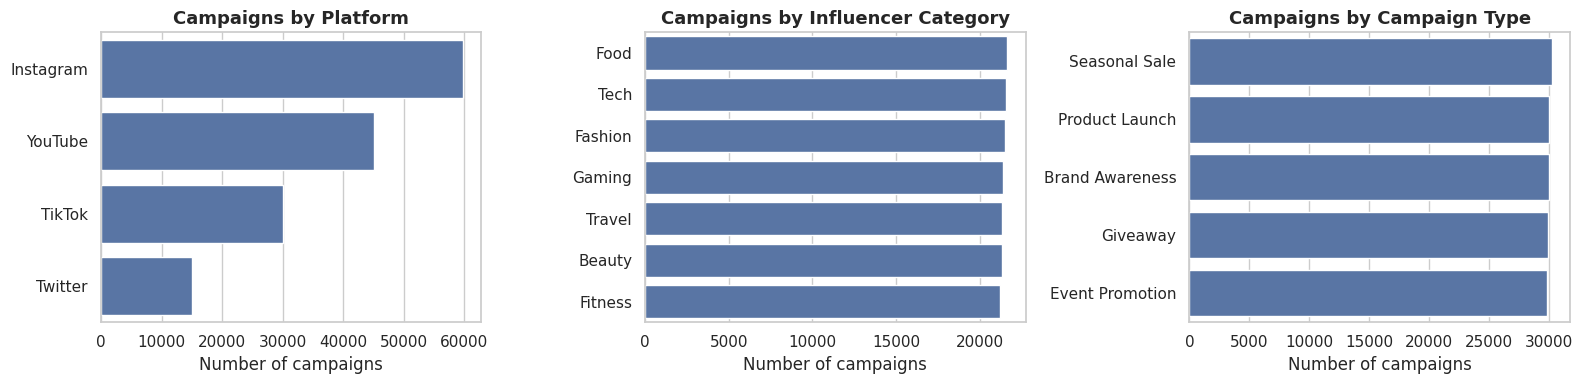

In [4]:
# Categorical distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["platform", "influencer_category", "campaign_type"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"Campaigns by {col.replace('_',' ').title()}")
    ax.set_xlabel("Number of campaigns")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [5]:
# Derived engagement/efficiency metrics that do NOT depend on any cost assumption
df["engagement_rate_pct"] = (df["engagements"] / df["estimated_reach"]) * 100          # engagement as % of reach
df["sales_per_1000_reach"] = (df["product_sales"] / df["estimated_reach"]) * 1000      # conversion efficiency
df["sales_per_engagement"] = df["product_sales"] / df["engagements"]                    # how "salesy" the audience is
df["sales_per_day"] = df["product_sales"] / df["campaign_duration_days"].replace(0, np.nan)

df[["engagement_rate_pct", "sales_per_1000_reach", "sales_per_engagement", "sales_per_day"]].describe()


,engagement_rate_pct,sales_per_1000_reach,sales_per_engagement,sales_per_day
count,"150,000.00","150,000.00","150,000.00","150,000.00"
mean,33.97,16.80,0.17,342.92
std,174.75,82.97,0.87,591.65
min,0.01,0.00,0.00,0.00
25%,5.01,2.51,0.02,83.52
50%,10.02,4.99,0.05,166.75
75%,20.01,9.91,0.10,322.95
max,"9,789.26","3,644.25",40.09,"4,998.00"


## 3. ROI Analysis

### Assumptions (EDIT THESE with your real numbers)

Since the raw data has no spend or price fields, we assume:
- a **cost per engagement (CPE)**, which varies by platform (reflecting typical differences in influencer rate cards), and
- an **average order value (AOV)** — the revenue generated per `product_sales` unit.

```
Cost   = engagements × CPE[platform]
Revenue = product_sales × AOV
ROI %   = (Revenue − Cost) / Cost × 100
```

Change the numbers below and every chart/table after this cell will update automatically.


In [6]:
# ---- EDIT THESE ASSUMPTIONS WITH REAL DATA IF AVAILABLE ----
CPE_BY_PLATFORM = {          # assumed cost ($) per engagement, illustrative industry-style benchmarks
    "Instagram": 0.10,
    "TikTok":    0.08,
    "YouTube":   0.15,
    "Twitter":   0.06,
}
AVERAGE_ORDER_VALUE = 45.0   # assumed $ revenue per unit of "product_sales"
# --------------------------------------------------------------

df["assumed_cost"] = df["platform"].map(CPE_BY_PLATFORM) * df["engagements"]
df["assumed_revenue"] = df["product_sales"] * AVERAGE_ORDER_VALUE
df["roi_pct"] = (df["assumed_revenue"] - df["assumed_cost"]) / df["assumed_cost"] * 100
df["cost_per_sale"] = df["assumed_cost"] / df["product_sales"].replace(0, np.nan)

df[["assumed_cost", "assumed_revenue", "roi_pct", "cost_per_sale"]].describe()


,assumed_cost,assumed_revenue,roi_pct,cost_per_sale
count,"150,000.00","150,000.00","150,000.00","149,981.00"
mean,"5,358.22","112,397.87","7,706.72",9.61
std,"3,560.47","64,945.02","41,575.08",108.82
min,6.00,0.00,-100.00,0.00
25%,"2,468.30","56,160.00",944.56,0.99
50%,"4,927.16","112,545.00","2,092.35",2.05
75%,"7,666.05","168,570.00","4,451.20",4.31
max,"14,998.95","224,955.00","2,921,395.33","12,483.15"


In [7]:
# ROI by platform
roi_platform = (
    df.groupby("platform")
      .agg(avg_roi_pct=("roi_pct", "mean"),
           median_roi_pct=("roi_pct", "median"),
           total_cost=("assumed_cost", "sum"),
           total_revenue=("assumed_revenue", "sum"),
           avg_cost_per_sale=("cost_per_sale", "mean"),
           campaigns=("campaign_id", "count"))
      .assign(overall_roi_pct=lambda d: (d["total_revenue"] - d["total_cost"]) / d["total_cost"] * 100)
      .sort_values("overall_roi_pct", ascending=False)
)
roi_platform


,avg_roi_pct,median_roi_pct,total_cost,total_revenue,avg_cost_per_sale,campaigns,overall_roi_pct
platform,,,,,,,
Twitter,"12,912.51","3,615.12","45,503,757.54","1,693,420,335.00",5.37,15058,"3,621.50"
TikTok,"9,340.78","2,722.68","119,515,256.72","3,364,212,825.00",7.05,29984,"2,714.88"
Instagram,"7,547.57","2,143.11","299,809,992.90","6,716,749,635.00",8.83,59819,"2,140.34"
YouTube,"5,095.56","1,388.70","338,903,672.85","5,085,297,630.00",13.75,45139,"1,400.51"


/tmp/ipykernel_543/2100959224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=roi_platform.loc[order, "overall_roi_pct"], y=order, ax=ax, palette="viridis")


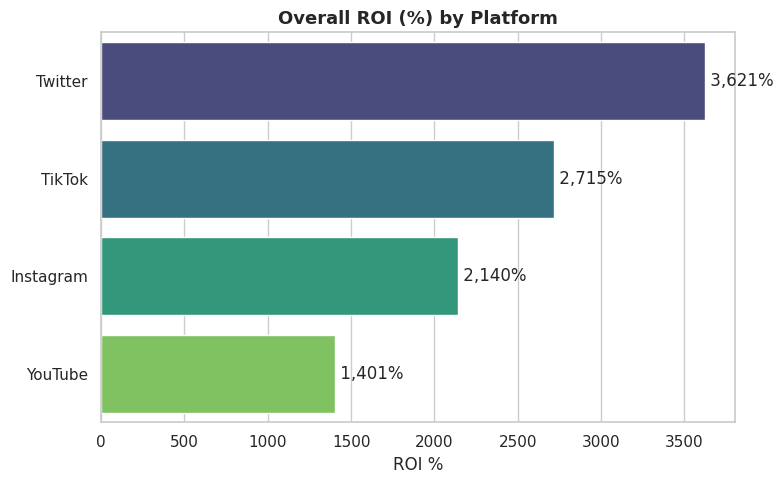

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
order = roi_platform.sort_values("overall_roi_pct", ascending=False).index
sns.barplot(x=roi_platform.loc[order, "overall_roi_pct"], y=order, ax=ax, palette="viridis")
ax.set_title("Overall ROI (%) by Platform")
ax.set_xlabel("ROI %")
ax.set_ylabel("")
for i, v in enumerate(roi_platform.loc[order, "overall_roi_pct"]):
    ax.text(v, i, f" {v:,.0f}%", va="center")
plt.tight_layout()
plt.show()


/tmp/ipykernel_543/1430344213.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=roi_category["overall_roi_pct"], y=order, ax=ax, palette="magma")


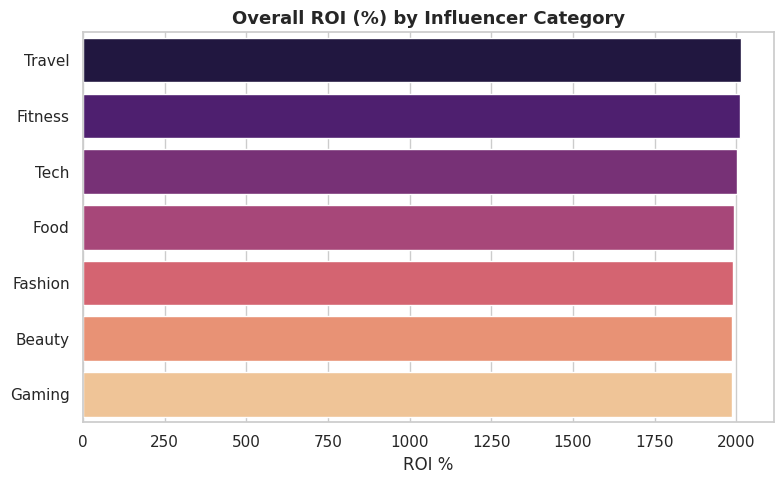

,total_cost,total_revenue,avg_cost_per_sale,campaigns,overall_roi_pct
influencer_category,,,,,
Travel,"113,928,012.63","2,409,321,015.00",10.31,21344,"2,014.77"
Fitness,"113,158,239.38","2,388,997,845.00",9.82,21211,"2,011.20"
Tech,"115,487,460.43","2,427,072,975.00",9.22,21545,"2,001.59"
Food,"116,693,801.59","2,442,616,560.00",9.34,21659,"1,993.18"
Fashion,"115,219,543.17","2,407,042,890.00",9.08,21502,"1,989.09"
Beauty,"114,625,482.16","2,393,188,155.00",9.11,21340,"1,987.83"
Gaming,"114,620,140.65","2,391,440,985.00",10.38,21399,"1,986.41"


In [9]:
# ROI by influencer category
roi_category = (
    df.groupby("influencer_category")
      .agg(total_cost=("assumed_cost", "sum"), total_revenue=("assumed_revenue", "sum"),
           avg_cost_per_sale=("cost_per_sale", "mean"), campaigns=("campaign_id", "count"))
      .assign(overall_roi_pct=lambda d: (d["total_revenue"] - d["total_cost"]) / d["total_cost"] * 100)
      .sort_values("overall_roi_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
order = roi_category.index
sns.barplot(x=roi_category["overall_roi_pct"], y=order, ax=ax, palette="magma")
ax.set_title("Overall ROI (%) by Influencer Category")
ax.set_xlabel("ROI %")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
roi_category


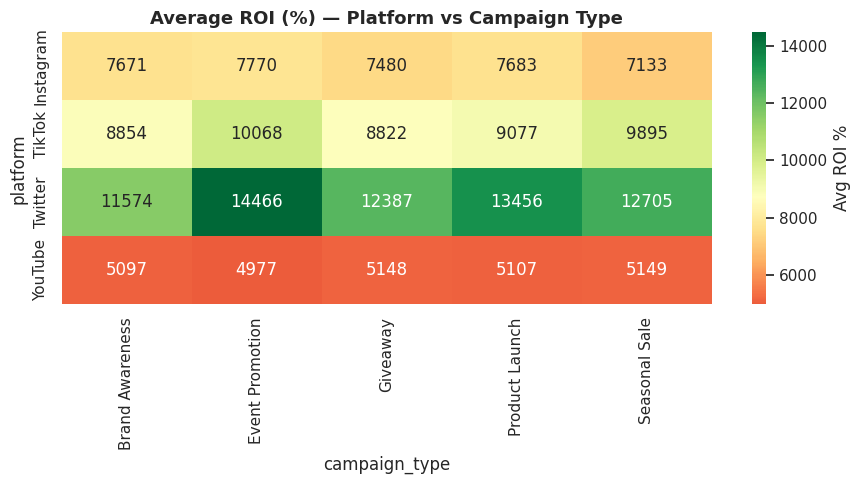

In [10]:
# ROI heatmap: platform x campaign_type
pivot_roi = df.pivot_table(index="platform", columns="campaign_type", values="roi_pct", aggfunc="mean")

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_roi, annot=True, fmt=".0f", cmap="RdYlGn", center=pivot_roi.values.mean(), ax=ax,
            cbar_kws={"label": "Avg ROI %"})
ax.set_title("Average ROI (%) — Platform vs Campaign Type")
plt.tight_layout()
plt.show()


## 4. Campaign Benchmarking

Comparing raw performance (engagement, reach, sales) and efficiency across campaign type, influencer category, and platform — independent of the cost assumptions above.


In [11]:
benchmark_type = df.groupby("campaign_type").agg(
    avg_engagements=("engagements", "mean"),
    avg_reach=("estimated_reach", "mean"),
    avg_sales=("product_sales", "mean"),
    avg_engagement_rate_pct=("engagement_rate_pct", "mean"),
    avg_sales_per_1000_reach=("sales_per_1000_reach", "mean"),
    avg_roi_pct=("roi_pct", "mean"),
    campaigns=("campaign_id", "count"),
).sort_values("avg_sales", ascending=False)
benchmark_type


,avg_engagements,avg_reach,avg_sales,avg_engagement_rate_pct,avg_sales_per_1000_reach,avg_roi_pct,campaigns
campaign_type,,,,,,,
Brand Awareness,"50,021.18","499,000.13","2,502.16",34.13,16.97,"7,525.28",29991
Seasonal Sale,"50,164.39","500,198.60","2,499.36",34.75,17.26,"7,656.79",30215
Giveaway,"50,556.22","499,827.43","2,498.17",34.74,17.00,"7,535.08",29952
Event Promotion,"49,853.34","499,005.74","2,495.96",33.09,16.45,"8,045.11",29833
Product Launch,"49,730.34","503,157.80","2,492.98",33.15,16.34,"7,773.22",30009


/tmp/ipykernel_543/455400511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=benchmark_type.loc[order, col], y=order, ax=ax, palette="crest")
/tmp/ipykernel_543/455400511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=benchmark_type.loc[order, col], y=order, ax=ax, palette="crest")
/tmp/ipykernel_543/455400511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=benchmark_type.loc[order, col], y=order, ax=ax, palette="crest")


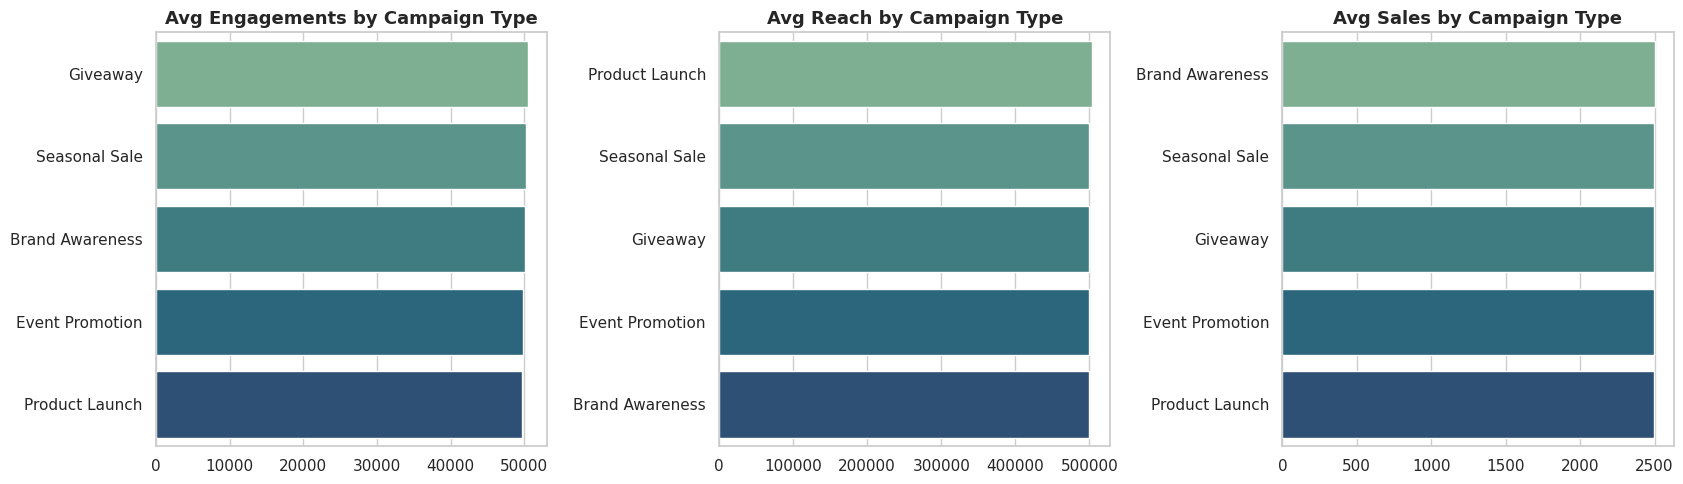

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics = [("avg_engagements", "Avg Engagements"), ("avg_reach", "Avg Reach"), ("avg_sales", "Avg Sales")]
for ax, (col, title) in zip(axes, metrics):
    order = benchmark_type.sort_values(col, ascending=False).index
    sns.barplot(x=benchmark_type.loc[order, col], y=order, ax=ax, palette="crest")
    ax.set_title(title + " by Campaign Type")
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


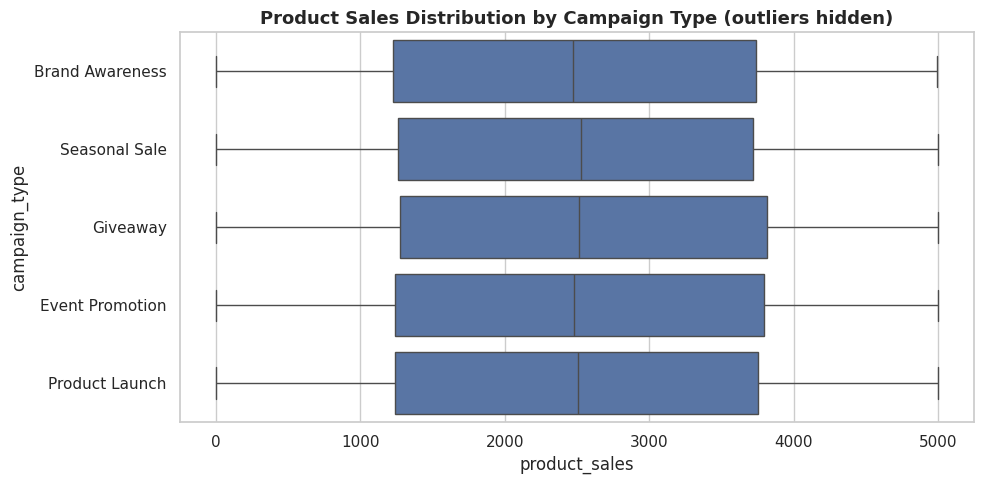

In [13]:
# Sales distribution by campaign type (boxplot, sampled for readability)
sample = df.sample(min(20000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(10, 5))
order = benchmark_type.sort_values("avg_sales", ascending=False).index
sns.boxplot(data=sample, x="product_sales", y="campaign_type", order=order, ax=ax, showfliers=False)
ax.set_title("Product Sales Distribution by Campaign Type (outliers hidden)")
plt.tight_layout()
plt.show()


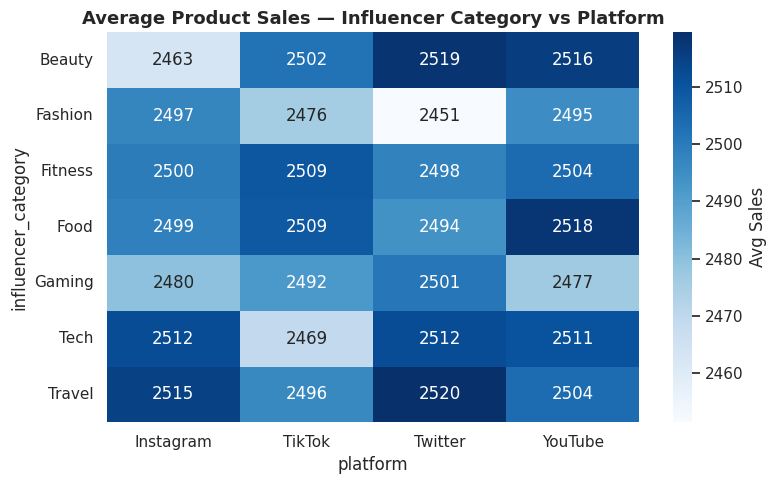

In [14]:
# Platform x Influencer Category performance matrix (avg sales)
pivot_sales = df.pivot_table(index="influencer_category", columns="platform", values="product_sales", aggfunc="mean")
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_sales, annot=True, fmt=".0f", cmap="Blues", ax=ax, cbar_kws={"label": "Avg Sales"})
ax.set_title("Average Product Sales — Influencer Category vs Platform")
plt.tight_layout()
plt.show()


## 5. Trend Analysis

Tracking engagement, reach, and sales over time. Campaigns are aggregated by **start month** so single-day spikes don't dominate the picture.

> Note: this dataset's dates increment sequentially one day per campaign row starting 2022‑01‑01, so the "trend" mainly reflects campaign order rather than seasonal/calendar effects in real-world data — treat it as a proxy for *how performance evolves across the campaign sequence*, and re-run this section as-is once real, non-sequential campaign dates are available.


In [15]:
monthly = (
    df.set_index("start_date")
      .resample("ME")
      .agg(engagements=("engagements", "mean"),
           estimated_reach=("estimated_reach", "mean"),
           product_sales=("product_sales", "mean"),
           roi_pct=("roi_pct", "mean"),
           campaigns=("campaign_id", "count"))
)
monthly.head()


,engagements,estimated_reach,product_sales,roi_pct,campaigns
start_date,,,,,
2022-01-31,"57,027.55","499,733.32","1,930.58","2,582.19",31
2022-02-28,"52,748.14","567,943.79","2,638.61","4,095.41",28
2022-03-31,"40,427.74","515,809.19","2,680.29","17,132.53",31
2022-04-30,"49,165.87","460,005.33","2,213.47","10,517.39",30
2022-05-31,"53,653.32","458,926.45","2,804.39","3,434.53",31


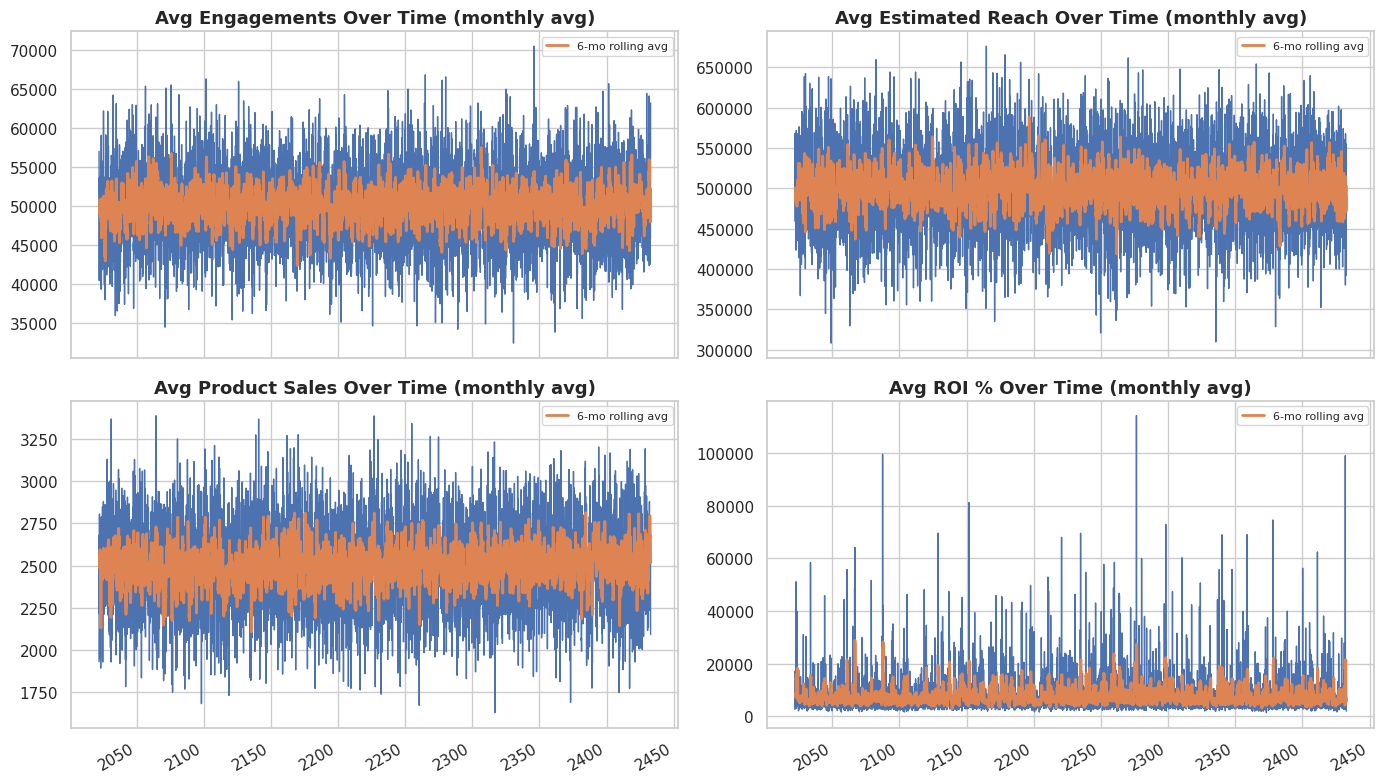

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
plot_cols = [("engagements", "Avg Engagements"), ("estimated_reach", "Avg Estimated Reach"),
             ("product_sales", "Avg Product Sales"), ("roi_pct", "Avg ROI %")]
for ax, (col, title) in zip(axes.flat, plot_cols):
    ax.plot(monthly.index, monthly[col], linewidth=1)
    ax.plot(monthly.index, monthly[col].rolling(6).mean(), linewidth=2, label="6-mo rolling avg")
    ax.set_title(title + " Over Time (monthly avg)")
    ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


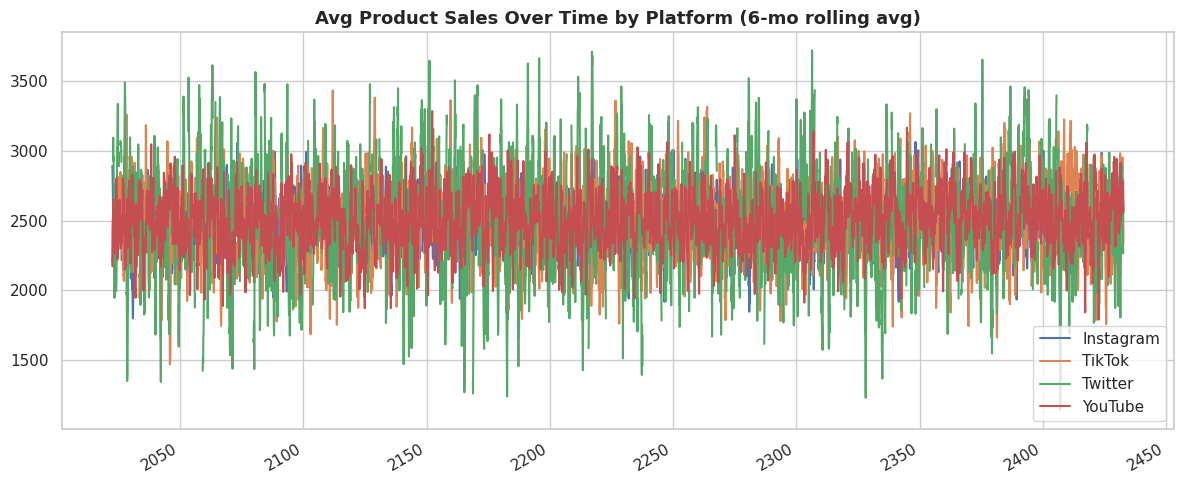

In [17]:
# Trend by platform (sales over time)
monthly_platform = (
    df.set_index("start_date")
      .groupby("platform")
      .resample("ME")["product_sales"]
      .mean()
      .reset_index()
)
fig, ax = plt.subplots(figsize=(12, 5))
for plat, grp in monthly_platform.groupby("platform"):
    ax.plot(grp["start_date"], grp["product_sales"].rolling(6).mean(), label=plat, linewidth=1.5)
ax.set_title("Avg Product Sales Over Time by Platform (6-mo rolling avg)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 6. Influencer Selection — Who to Partner With Next

We combine three efficiency signals — **ROI, sales-per-1000-reach (conversion efficiency), and engagement rate** — into a single 0–100 composite score per influencer category and per campaign type, so the "best" option isn't dominated by any one metric.


In [18]:
def score_table(df, group_col):
    g = df.groupby(group_col).agg(
        avg_roi_pct=("roi_pct", "mean"),
        avg_sales_per_1000_reach=("sales_per_1000_reach", "mean"),
        avg_engagement_rate_pct=("engagement_rate_pct", "mean"),
        avg_sales=("product_sales", "mean"),
        campaigns=("campaign_id", "count"),
    )
    # min-max normalize each metric to 0-100, then average -> composite score
    norm = g[["avg_roi_pct", "avg_sales_per_1000_reach", "avg_engagement_rate_pct"]].apply(
        lambda s: (s - s.min()) / (s.max() - s.min()) * 100
    )
    g["composite_score"] = norm.mean(axis=1)
    return g.sort_values("composite_score", ascending=False)

category_scores = score_table(df, "influencer_category")
type_scores = score_table(df, "campaign_type")

print("=== Influencer Category Ranking ===")
display(category_scores)
print("\n=== Campaign Type Ranking ===")
display(type_scores)


=== Influencer Category Ranking ===


,avg_roi_pct,avg_sales_per_1000_reach,avg_engagement_rate_pct,avg_sales,campaigns,composite_score
influencer_category,,,,,,
Fashion,"7,644.90",17.69,35.65,"2,487.67",21502,76.97
Tech,"7,937.82",17.06,34.50,"2,503.36",21545,71.01
Travel,"7,413.24",17.19,36.02,"2,508.46",21344,56.62
Food,"7,754.76",16.68,33.46,"2,506.13",21659,42.62
Gaming,"7,971.21",16.24,32.60,"2,483.44",21399,38.56
Fitness,"7,537.23",16.71,33.09,"2,502.89",21211,26.80
Beauty,"7,683.69",16.04,32.48,"2,492.13",21340,16.16



=== Campaign Type Ranking ===


,avg_roi_pct,avg_sales_per_1000_reach,avg_engagement_rate_pct,avg_sales,campaigns,composite_score
campaign_type,,,,,,
Seasonal Sale,"7,656.79",17.26,34.75,"2,499.36",30215,75.10
Giveaway,"7,535.08",17.00,34.74,"2,498.17",29952,57.73
Brand Awareness,"7,525.28",16.97,34.13,"2,502.16",29991,43.66
Event Promotion,"8,045.11",16.45,33.09,"2,495.96",29833,37.28
Product Launch,"7,773.22",16.34,33.15,"2,492.98",30009,17.04


/tmp/ipykernel_543/3261644823.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_scores["composite_score"], y=category_scores.index, ax=axes[0], palette="rocket")
/tmp/ipykernel_543/3261644823.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_scores["composite_score"], y=type_scores.index, ax=axes[1], palette="rocket")


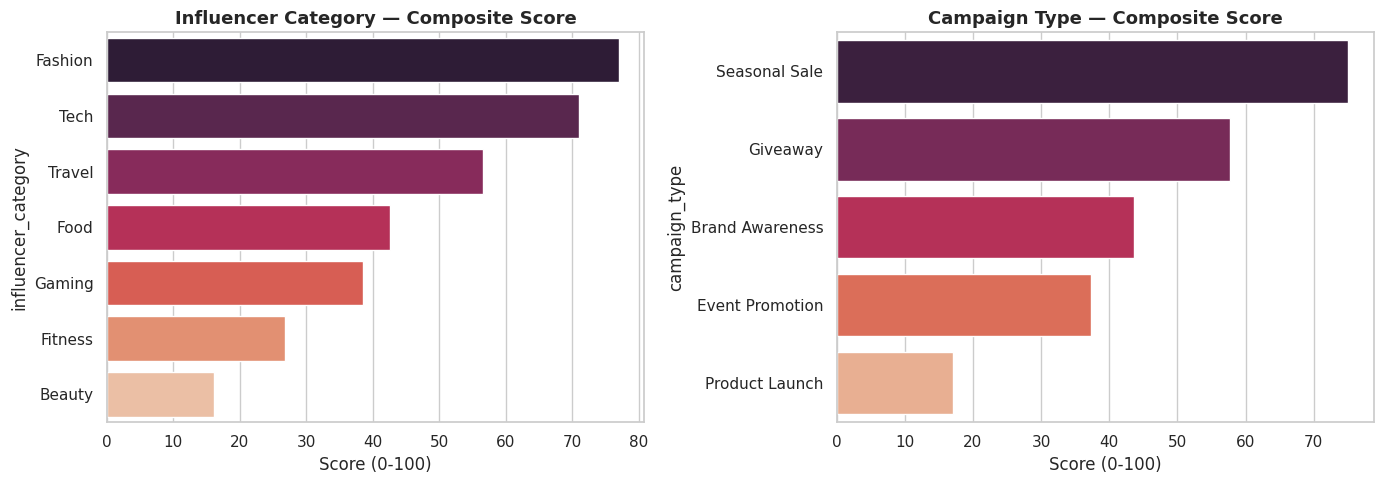

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=category_scores["composite_score"], y=category_scores.index, ax=axes[0], palette="rocket")
axes[0].set_title("Influencer Category — Composite Score")
axes[0].set_xlabel("Score (0-100)")

sns.barplot(x=type_scores["composite_score"], y=type_scores.index, ax=axes[1], palette="rocket")
axes[1].set_title("Campaign Type — Composite Score")
axes[1].set_xlabel("Score (0-100)")
plt.tight_layout()
plt.show()


In [20]:
# Best platform x category x campaign_type combinations by ROI (min campaign count filter for reliability)
combo = (
    df.groupby(["platform", "influencer_category", "campaign_type"])
      .agg(avg_roi_pct=("roi_pct", "mean"), campaigns=("campaign_id", "count"))
      .reset_index()
)
combo_reliable = combo[combo["campaigns"] >= 30].sort_values("avg_roi_pct", ascending=False)
print("Top 10 highest-ROI combinations (min. 30 campaigns for reliability):")
combo_reliable.head(10)


Top 10 highest-ROI combinations (min. 30 campaigns for reliability):


,platform,influencer_category,campaign_type,avg_roi_pct,campaigns
88,Twitter,Food,Product Launch,"20,944.54",421
81,Twitter,Fitness,Event Promotion,"20,668.57",430
71,Twitter,Beauty,Event Promotion,"17,433.68",434
85,Twitter,Food,Brand Awareness,"16,437.82",441
92,Twitter,Gaming,Giveaway,"15,504.94",411
82,Twitter,Fitness,Giveaway,"15,408.61",410
96,Twitter,Tech,Event Promotion,"15,343.92",442
73,Twitter,Beauty,Product Launch,"15,216.03",423
79,Twitter,Fashion,Seasonal Sale,"14,908.77",456
76,Twitter,Fashion,Event Promotion,"14,657.78",464


## 7. Executive Summary

In [21]:
top_platform = roi_platform["overall_roi_pct"].idxmax()
top_category = category_scores["composite_score"].idxmax()
top_campaign_type = type_scores["composite_score"].idxmax()
best_combo = combo_reliable.iloc[0]

print("KEY TAKEAWAYS")
print("=" * 60)
print(f"• Highest-ROI platform:          {top_platform} ({roi_platform.loc[top_platform, 'overall_roi_pct']:.0f}% overall ROI)")
print(f"• Highest-scoring influencer category: {top_category} (score {category_scores.loc[top_category, 'composite_score']:.1f}/100)")
print(f"• Highest-scoring campaign type:  {top_campaign_type} (score {type_scores.loc[top_campaign_type, 'composite_score']:.1f}/100)")
print(f"• Best reliable combo:            {best_combo['platform']} x {best_combo['influencer_category']} x "
      f"{best_combo['campaign_type']} ({best_combo['avg_roi_pct']:.0f}% avg ROI, n={int(best_combo['campaigns'])})")
print()
print("Reminder: ROI figures depend on the CPE/AOV assumptions set in Section 3 —")
print("swap in real spend and pricing data for decision-grade numbers.")


KEY TAKEAWAYS
• Highest-ROI platform:          Twitter (3621% overall ROI)
• Highest-scoring influencer category: Fashion (score 77.0/100)
• Highest-scoring campaign type:  Seasonal Sale (score 75.1/100)
• Best reliable combo:            Twitter x Food x Product Launch (20945% avg ROI, n=421)

Reminder: ROI figures depend on the CPE/AOV assumptions set in Section 3 —
swap in real spend and pricing data for decision-grade numbers.


---
### Next steps
- Replace `CPE_BY_PLATFORM` and `AVERAGE_ORDER_VALUE` with actual spend/pricing data for accurate ROI.
- If real spend-per-campaign is available, merge it in and drop the assumption cell entirely.
- Consider a regression/uplift model to isolate the causal effect of campaign type/category on sales once spend data is added.
